Attempting to replicate the results from Gelli+24

In [1]:
from escripts import eMCMC
import importlib
from escripts import eplots
Plotting = eplots.Plotting()
import time

In [2]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_fixed.txt',
                       '/Users/eb35267/Desktop/code/home/data/Donnan24_GAL.txt', 
                      '/Users/eb35267/Desktop/code/home/data/Mcleod_24.txt']
data_labels = ['Bouwens+21', 'Donnan+24', 'McLeod+24']

In [3]:
eMCMC.get_default_dict()

,fit,value,start,lower,upper,label
alpha,True,0.6,0.6,0,4,$\alpha$
dalphadz,True,0,0.01,-0.5,0.5,$d\alpha/dz$
beta,True,-0.5,-0.5,-1,0,$\beta$
dbetadz,True,0,0.01,-0.5,0.5,$d\beta/dz$
logMc,True,12,12,9,16,$\log(M_c)$
dlogMcdz,True,0,0.01,-0.5,0.5,$d\log(M_c)/dz$
loge,True,-0.5,-1,-1,1,$\log(\epsilon_0)$
dlogedz,True,0,0.01,-0.5,0.5,$d\log(\epsilon_0)/dz$
sig,True,0,0.5,0,6,"$\sigma_{\rm{UV}, 10}$"
dsigdz,True,0,0.01,-0.5,0.5,$d\sigma_{\rm{UV}}/dz$


In [4]:
custom_params = {'dalphadz': {'fit':False, 'value':0},
                'dbetadz': {'fit':False, 'value':0},
                'dlogMcdz': {'fit':False, 'value':0},
                'dlogedz': {'fit':False, 'value':0},
                'dsigdz': {'fit':False, 'value':0}}

In [5]:
param_data = eMCMC.build_param_data(custom_params)

In [6]:
my_UVLF = eMCMC.UVLF(file_names, data_labels, param_data)

In [7]:
ICs = my_UVLF.generate_ICs()

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


In [8]:
# Run MCMC
t = time.time()
Nsteps=2000
my_UVLF.sampler.run_mcmc(ICs, Nsteps) 
# Get flat sample from the MCMC
samples = my_UVLF.sampler.get_chain(discard = 400, flat=True)
print(time.time()-t)

55.93569207191467


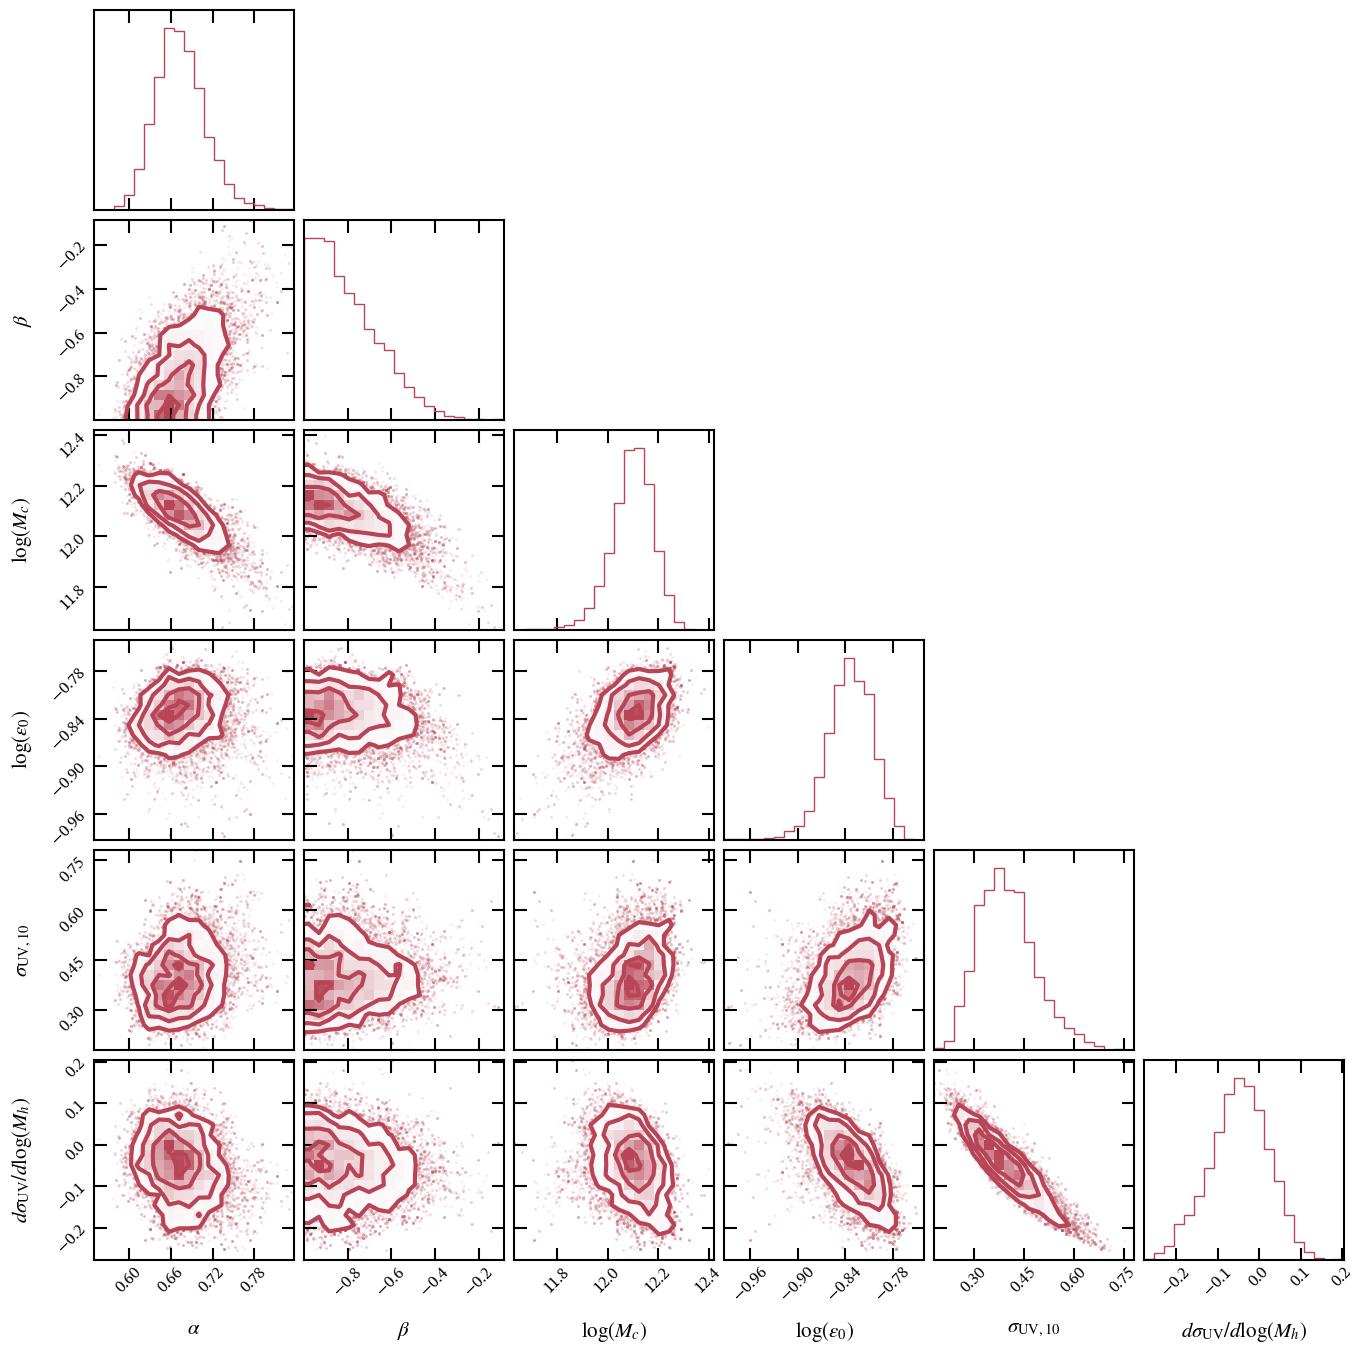

In [9]:
corner = Plotting.plot_corner(samples, my_UVLF)

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:148: RuntimeWarning: invalid value encountered in log10
  ax[i].plot(plot_xdat, np.log10(my_UVLF.UVLF_wrapper(zdat,zerr,plot_xdat, plot_xerr,sample)), alpha=nsamples/3500, color = self.red,


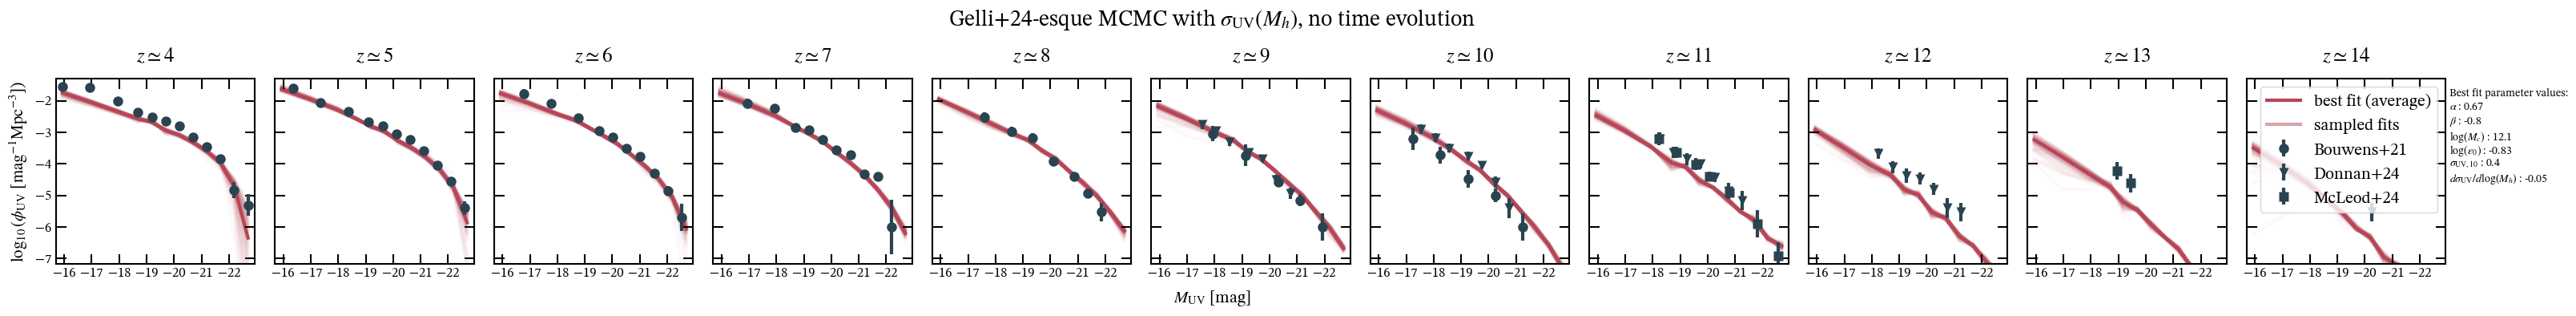

In [10]:
te_plot = Plotting.plot_evolving_UVLF_fit(samples, my_UVLF, title = r'Gelli+24-esque MCMC with $\sigma_{\rm{UV}}(M_h)$, no time evolution')
#te_plot.savefig('/Users/eb35267/Desktop/code/figures/Gelli_comparison/no_time_evolution_with_jwst_data.png', bbox_inches='tight')